In [68]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [69]:
AGG_LABELS = {
    "sum": "Sum",
    "deepsets": "DeepSets",
    "settransformer": "SetTransformer",
    "hopfield": "Hopfield",
    "ift": "IFT",
}

UPDATE_LABELS = {
    "tgn_gru": "TGN-GRU",
    "lnn": "LNN",
    "hnn": "HNN",
    "hopfield_update": "Hopfield Update",
    "ift_update": "IFT Update",
}

PARAM_COLS = [
    "dataset",
    "aggregator",
    "update",
    "do",
    "sdo",
    "time",
    "ift_kappa_param",
    "dt",
    "gamma",
    "k0",
    "cap",
    "seed",
]

LABEL_MAP = {
    "dataset": "dataset",
    "aggregator": "agg",
    "update": "upd",
    "do": "do",
    "sdo": "sdo",
    "time": "time",
    "ift_kappa_param": "kappa",
    "dt": "dt",
    "gamma": "gamma",
    "k0": "k0",
    "cap": "cap",
}

In [70]:
def pretty_agg(x):
    if pd.isna(x):
        return "Unknown Aggregator"
    return AGG_LABELS.get(str(x), str(x))

def pretty_upd(x):
    if pd.isna(x):
        return "Unknown Update"
    return UPDATE_LABELS.get(str(x), str(x))

def pretty_combo(row):
    return f"{pretty_agg(row['aggregator'])}/{pretty_upd(row['update'])}"

def parse_bool(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return np.nan
    if isinstance(x, bool):
        return x
    s = str(x).strip().lower()
    if s == "true":
        return True
    if s == "false":
        return False
    return np.nan

def parse_float(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return np.nan
    try:
        return float(x)
    except (TypeError, ValueError):
        return np.nan

def parse_cap(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return np.nan
    s = str(x).strip().lower()
    if s == "none":
        return "none"
    try:
        return float(s)
    except ValueError:
        return x

def parse_name_config(name):
    """
    Parse strings like:
    Reddit_agg=sum|update=ift_update|do=0.0|sdo=0.0|time=False|softplus|dt=0.05|gamma=0.0|k0=0.1|cap=none
    """
    parsed = {}

    if pd.isna(name):
        return parsed

    s = str(name)

    rest = s
    if "_agg=" in s:
        dataset_prefix, rest = s.split("_", 1)
        parsed["dataset_from_name"] = dataset_prefix

    parts = rest.split("|")
    positional = []

    for part in parts:
        if "=" in part:
            k, v = part.split("=", 1)
            if k == "agg":
                k = "aggregator"
            parsed[k] = v
        else:
            positional.append(part)

    if positional:
        parsed["ift_kappa_param"] = positional[0]

    return parsed

def infer_dataset(row):
    dataset = row.get("dataset")
    if pd.notna(dataset):
        return dataset

    name = str(row.get("name", ""))
    if "__" in name:
        prefix = name.split("__", 1)[0]
        if prefix:
            return prefix

    if "_agg=" in name:
        return name.split("_agg=", 1)[0]

    return np.nan

def _as_list(values):
    if values is None:
        return None
    if isinstance(values, (list, tuple, set, pd.Index, np.ndarray)):
        return list(values)
    return [values]

In [71]:
# summary_path = Path("/home/akapociu/ift/interactiondynamics/results/iftxbaseline_all_ds.jsonl")
summary_path = Path("/home/akapociu/ift/interactiondynamics/results/nbody_ift_hp_test_summary.jsonl")


rows = []
with open(summary_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

print(f"Loaded {len(rows)} rows from {summary_path}")

Loaded 560 rows from /home/akapociu/ift/interactiondynamics/results/nbody_ift_hp_test_summary.jsonl


In [72]:
flat_rows = []

for r in rows:
    name_parts = parse_name_config(r.get("name"))
    best = r.get("best_snapshot", {}) or {}
    final = r.get("final_snapshot", {}) or {}

    row = {
        "dataset": infer_dataset(r),
        "name": r.get("name"),
        "seed": r.get("seed"),
        "epochs": r.get("epochs"),
        "wall_sec": r.get("wall_sec"),
        "best_epoch": r.get("best_epoch"),
        "best_val_mrr": r.get("best_val_mrr"),

        "aggregator": name_parts.get("aggregator"),
        "update": name_parts.get("update"),
        "do": parse_float(name_parts.get("do")),
        "sdo": parse_float(name_parts.get("sdo")),
        "time": parse_bool(name_parts.get("time")),
        "ift_kappa_param": name_parts.get("ift_kappa_param"),
        "dt": parse_float(name_parts.get("dt")),
        "gamma": parse_float(name_parts.get("gamma")),
        "k0": parse_float(name_parts.get("k0")),
        "cap": parse_cap(name_parts.get("cap")),
    }

    row["dropout"] = row["do"]
    row["scorer_dropout"] = row["sdo"]
    row["time_features"] = row["time"]

    row.update({
        "best_val_loss": best.get("val", {}).get("loss"),
        "best_val_mrr_from_snapshot": best.get("val", {}).get("mrr"),
        "best_test_mrr": best.get("test", {}).get("mrr"),
        "best_test_loss": best.get("test", {}).get("loss"),
        "best_train_mrr": best.get("train_eval", {}).get("mrr"),
        "best_val_early_mrr": best.get("val", {}).get("early_mrr"),
        "best_val_late_mrr": best.get("val", {}).get("late_mrr"),
        "best_test_early_mrr": best.get("test", {}).get("early_mrr"),
        "best_test_late_mrr": best.get("test", {}).get("late_mrr"),
        "final_val_mrr": final.get("val", {}).get("mrr"),
        "final_test_mrr": final.get("test", {}).get("mrr"),
        "final_train_mrr": final.get("train_eval", {}).get("mrr"),
    })

    flat_rows.append(row)

df = pd.DataFrame(flat_rows)

df["aggregator_clean"] = df["aggregator"].map(pretty_agg)
df["update_clean"] = df["update"].map(pretty_upd)
df["combo_clean"] = df.apply(pretty_combo, axis=1)

print(df.shape)
display(df.head())

(560, 35)


,dataset,name,seed,epochs,wall_sec,best_epoch,best_val_mrr,aggregator,update,do,...,best_val_early_mrr,best_val_late_mrr,best_test_early_mrr,best_test_late_mrr,final_val_mrr,final_test_mrr,final_train_mrr,aggregator_clean,update_clean,combo_clean
0,N,N__agg=ift|update=ift_update|do=0.0|sdo=0.0|ti...,0,6,193.001262,4,0.335401,None,ift_update,0.0,...,0.340151,0.335236,0.368398,0.344949,0.291740,0.301180,0.250446,Unknown Aggregator,IFT Update,Unknown Aggregator/IFT Update
1,N,N__agg=ift|update=ift_update|do=0.0|sdo=0.0|ti...,0,6,191.369401,6,0.343317,None,ift_update,0.0,...,0.340357,0.343420,0.388272,0.351921,0.343317,0.353137,0.248007,Unknown Aggregator,IFT Update,Unknown Aggregator/IFT Update
2,N,N__agg=ift|update=ift_update|do=0.0|sdo=0.0|ti...,0,6,191.404267,2,0.338251,None,ift_update,0.0,...,0.301923,0.339508,0.325021,0.340956,0.298356,0.299872,0.208239,Unknown Aggregator,IFT Update,Unknown Aggregator/IFT Update
3,N,N__agg=ift|update=ift_update|do=0.0|sdo=0.0|ti...,0,6,191.449416,5,0.335255,None,ift_update,0.0,...,0.345485,0.334901,0.398275,0.353446,0.329757,0.348069,0.241177,Unknown Aggregator,IFT Update,Unknown Aggregator/IFT Update
4,N,N__agg=ift|update=ift_update|do=0.0|sdo=0.0|ti...,0,6,191.373777,3,0.333418,None,ift_update,0.0,...,0.342933,0.333089,0.377166,0.341314,0.284998,0.311087,0.251619,Unknown Aggregator,IFT Update,Unknown Aggregator/IFT Update


In [73]:
def show_filter_options(frame, columns=PARAM_COLS, max_unique=20):
    rows = []
    for col in columns:
        if col not in frame.columns:
            continue
        values = sorted(frame[col].drop_duplicates().tolist(), key=lambda x: str(x))
        rows.append({
            "column": col,
            "n_unique": len(values),
            "sample_values": values[:max_unique],
        })
    return pd.DataFrame(rows)

def filter_runs(frame, filters, verbose=True):
    out = frame.copy()

    for key, allowed in filters.items():
        if allowed is None:
            continue
        if key not in out.columns:
            raise KeyError(f"{key} is not a column in the dataframe")

        allowed = _as_list(allowed)
        before = len(out)
        out = out[out[key].isin(allowed)].copy()

        if verbose:
            print(f"{key}: kept {len(out)}/{before} rows using {allowed}")

    return out

In [74]:
display(show_filter_options(df))

,column,n_unique,sample_values
0,dataset,5,"[N, b, d, o, y]"
1,aggregator,1,[None]
2,update,1,[ift_update]
3,do,2,"[0.0, 0.3]"
4,sdo,1,[0.0]
5,time,1,[False]
6,ift_kappa_param,1,[softplus]
7,dt,4,"[0.01, 0.05, 0.1, 0.2]"
8,gamma,4,"[0.0, 0.01, 0.05, 0.1]"
9,k0,4,"[0.1, 0.5, 1.0, 2.0]"


In [75]:
FOCUS_FILTERS = {
    "dataset": None,            # e.g. ["Wikipedia", "Reddit"]
    "aggregator": None,         # e.g. ["sum", "ift", "deepsets"]
    "update": None,             # e.g. ["tgn_gru", "ift_update"]
    "do": [0.0, 0.3],           # dropout
    "sdo": None,
    "time": None,
    "ift_kappa_param": None,
    "dt": [0.01, 0.05, 0.1, 0.2],
    "gamma": [0.0, 0.01, 0.05, 0.1],
    "k0": [0.1, 0.5, 1.0, 2.0],
    "cap": None,
    "seed": None,
}

focus_df = filter_runs(df, FOCUS_FILTERS, verbose=True).copy()

active_filters = {k: v for k, v in FOCUS_FILTERS.items() if v is not None}
print("\nActive filters:", active_filters if active_filters else "None")
print("Selected rows:", len(focus_df))

display(focus_df.head())

do: kept 560/560 rows using [0.0, 0.3]
dt: kept 560/560 rows using [0.01, 0.05, 0.1, 0.2]
gamma: kept 560/560 rows using [0.0, 0.01, 0.05, 0.1]
k0: kept 560/560 rows using [0.1, 0.5, 1.0, 2.0]

Active filters: {'do': [0.0, 0.3], 'dt': [0.01, 0.05, 0.1, 0.2], 'gamma': [0.0, 0.01, 0.05, 0.1], 'k0': [0.1, 0.5, 1.0, 2.0]}
Selected rows: 560


,dataset,name,seed,epochs,wall_sec,best_epoch,best_val_mrr,aggregator,update,do,...,best_val_early_mrr,best_val_late_mrr,best_test_early_mrr,best_test_late_mrr,final_val_mrr,final_test_mrr,final_train_mrr,aggregator_clean,update_clean,combo_clean
0,N,N__agg=ift|update=ift_update|do=0.0|sdo=0.0|ti...,0,6,193.001262,4,0.335401,None,ift_update,0.0,...,0.340151,0.335236,0.368398,0.344949,0.291740,0.301180,0.250446,Unknown Aggregator,IFT Update,Unknown Aggregator/IFT Update
1,N,N__agg=ift|update=ift_update|do=0.0|sdo=0.0|ti...,0,6,191.369401,6,0.343317,None,ift_update,0.0,...,0.340357,0.343420,0.388272,0.351921,0.343317,0.353137,0.248007,Unknown Aggregator,IFT Update,Unknown Aggregator/IFT Update
2,N,N__agg=ift|update=ift_update|do=0.0|sdo=0.0|ti...,0,6,191.404267,2,0.338251,None,ift_update,0.0,...,0.301923,0.339508,0.325021,0.340956,0.298356,0.299872,0.208239,Unknown Aggregator,IFT Update,Unknown Aggregator/IFT Update
3,N,N__agg=ift|update=ift_update|do=0.0|sdo=0.0|ti...,0,6,191.449416,5,0.335255,None,ift_update,0.0,...,0.345485,0.334901,0.398275,0.353446,0.329757,0.348069,0.241177,Unknown Aggregator,IFT Update,Unknown Aggregator/IFT Update
4,N,N__agg=ift|update=ift_update|do=0.0|sdo=0.0|ti...,0,6,191.373777,3,0.333418,None,ift_update,0.0,...,0.342933,0.333089,0.377166,0.341314,0.284998,0.311087,0.251619,Unknown Aggregator,IFT Update,Unknown Aggregator/IFT Update


In [76]:
VALUE_FORMATTERS = {
    "dataset": lambda x: str(x) if pd.notna(x) else "NA",
    "aggregator": pretty_agg,
    "update": pretty_upd,
    "do": lambda x: f"{x:g}" if pd.notna(x) else "NA",
    "sdo": lambda x: f"{x:g}" if pd.notna(x) else "NA",
    "time": lambda x: "True" if x is True else "False" if x is False else "NA",
    "ift_kappa_param": lambda x: str(x) if pd.notna(x) else "NA",
    "dt": lambda x: f"{x:g}" if pd.notna(x) else "NA",
    "gamma": lambda x: f"{x:g}" if pd.notna(x) else "NA",
    "k0": lambda x: f"{x:g}" if pd.notna(x) else "NA",
    "cap": lambda x: str(x) if pd.notna(x) else "NA",
}

def pretty_value(x):
    if pd.isna(x):
        return "NA"
    if isinstance(x, bool):
        return str(x)
    if isinstance(x, float):
        return f"{x:g}"
    return str(x)

def format_value(col, val):
    formatter = VALUE_FORMATTERS.get(col, pretty_value)
    return formatter(val)

def choose_compare_cols(frame, candidate_cols=None):
    if candidate_cols is None:
        candidate_cols = [c for c in PARAM_COLS if c != "seed"]

    chosen = []
    for col in candidate_cols:
        if col not in frame.columns:
            continue

        vals = frame[col]
        non_na = vals.dropna()

        if len(non_na) == 0:
            continue

        if non_na.nunique() > 1:
            chosen.append(col)
            continue

        if vals.fillna("NA").nunique() > 1:
            chosen.append(col)

    return chosen

def build_config_id(frame, compare_cols=None):
    if compare_cols is None:
        compare_cols = choose_compare_cols(frame)

    out = frame.copy()

    if len(out) == 0:
        out["config_id"] = pd.Series(dtype=object)
        return out, compare_cols

    if not compare_cols:
        out["config_id"] = "all_selected_runs"
        return out, compare_cols

    out["config_id"] = out[compare_cols].apply(
        lambda row: " | ".join(
            f"{LABEL_MAP.get(col, col)}={format_value(col, row[col])}"
            for col in compare_cols
        ),
        axis=1,
    )

    return out, compare_cols

In [77]:
focus_with_ids, compare_cols = build_config_id(focus_df)

print("Compare columns used:", compare_cols if compare_cols else "None")
display(focus_with_ids[["config_id", "seed", "best_val_mrr", "best_test_mrr"]].head(10))

Compare columns used: ['dataset', 'do', 'dt', 'gamma', 'k0']


,config_id,seed,best_val_mrr,best_test_mrr
0,dataset=N | do=0 | dt=0.01 | gamma=0 | k0=0.1,0,0.335401,0.345733
1,dataset=N | do=0 | dt=0.01 | gamma=0 | k0=0.5,0,0.343317,0.353137
2,dataset=N | do=0 | dt=0.01 | gamma=0.01 | k0=0.1,0,0.338251,0.340423
3,dataset=N | do=0 | dt=0.01 | gamma=0.01 | k0=0.5,0,0.335255,0.354945
4,dataset=N | do=0 | dt=0.01 | gamma=0.05 | k0=0.1,0,0.333418,0.342513
5,dataset=N | do=0 | dt=0.01 | gamma=0.05 | k0=0.5,0,0.333462,0.344992
6,dataset=N | do=0 | dt=0.01 | gamma=0.1 | k0=0.1,0,0.356397,0.368316
7,dataset=N | do=0 | dt=0.01 | gamma=0.1 | k0=0.5,0,0.345591,0.359571
8,dataset=N | do=0 | dt=0.05 | gamma=0 | k0=0.1,0,0.431278,0.424178
9,dataset=N | do=0 | dt=0.05 | gamma=0 | k0=0.5,0,0.546743,0.517082


In [78]:
metric = "best_val_mrr"   # or best_test_mrr, final_val_mrr, etc.

plot_df = (
    focus_with_ids
    .groupby("config_id", dropna=False)
    .agg(
        mean_metric=(metric, "mean"),
        std_metric=(metric, "std"),
        n_seeds=("seed", "nunique"),
    )
    .reset_index()
    .sort_values("mean_metric", ascending=False)
)

display(plot_df)

,config_id,mean_metric,std_metric,n_seeds
108,dataset=N | do=0.3 | dt=0.2 | gamma=0.1 | k0=0.1,0.779240,NaN,1
391,dataset=o | do=0 | dt=0.2 | gamma=0.1 | k0=2,0.777795,NaN,1
167,dataset=b | do=0 | dt=0.2 | gamma=0.1 | k0=2,0.774391,NaN,1
279,dataset=d | do=0 | dt=0.2 | gamma=0.1 | k0=2,0.773183,NaN,1
163,dataset=b | do=0 | dt=0.2 | gamma=0.05 | k0=2,0.769475,NaN,1
...,...,...,...,...
112,dataset=b | do=0 | dt=0.01 | gamma=0 | k0=0.1,0.316413,NaN,1
280,dataset=d | do=0.3 | dt=0.01 | gamma=0 | k0=0.1,0.315940,NaN,1
451,dataset=y | do=0 | dt=0.01 | gamma=0.01 | k0=0.5,0.314976,NaN,1
116,dataset=b | do=0 | dt=0.01 | gamma=0.05 | k0=0.1,0.314620,NaN,1


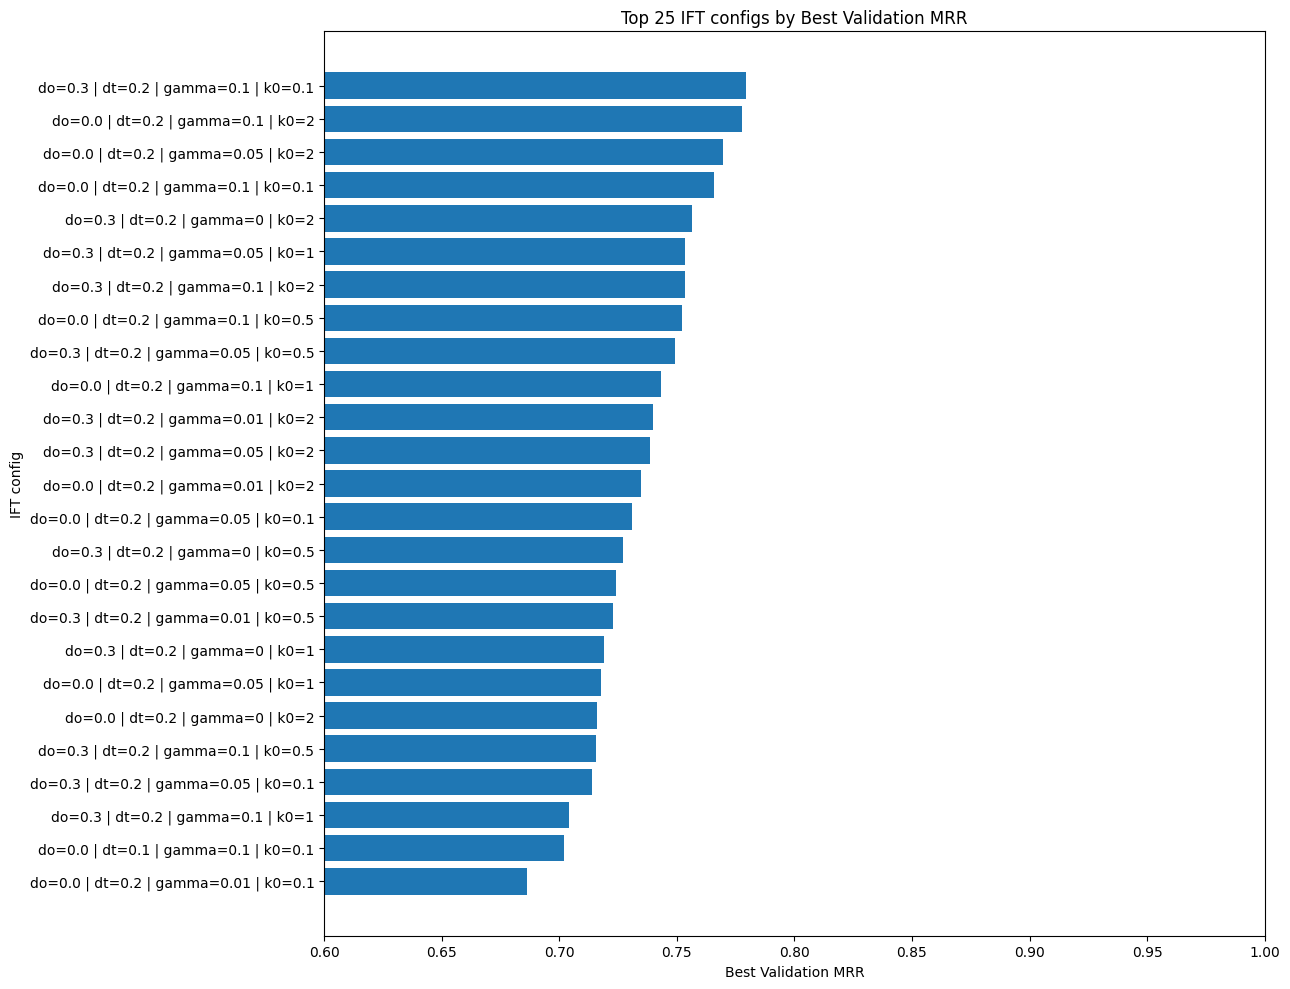

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

metric = "best_val_mrr"

plot_df = focus_with_ids.copy()

plot_df["pretty_label"] = plot_df.apply(
    lambda r: f"do={r['do']:.1f} | dt={r['dt']:.3g} | gamma={r['gamma']:.3g} | k0={r['k0']:.3g}",
    axis=1
)

plot_df = (
    plot_df.sort_values(metric, ascending=False)
    .drop_duplicates(subset=["pretty_label"])
)

top25 = plot_df.nlargest(25, metric).sort_values(metric, ascending=True)

plt.figure(figsize=(13, 10))
plt.barh(top25["pretty_label"], top25[metric])
plt.xlim(0.6, 1.0)
plt.xlabel("Best Validation MRR")
plt.ylabel("IFT config")
plt.title("Top 25 IFT configs by Best Validation MRR")
plt.tight_layout()
plt.show()

In [81]:
top25_display = top25[
    ["do", "dt", "gamma", "k0", "best_val_mrr", "best_epoch"]
].sort_values("best_val_mrr", ascending=False).reset_index(drop=True)

display(top25_display)

,do,dt,gamma,k0,best_val_mrr,best_epoch
0,0.3,0.2,0.10,0.1,0.779240,5
1,0.0,0.2,0.10,2.0,0.777795,1
2,0.0,0.2,0.05,2.0,0.769475,1
3,0.0,0.2,0.10,0.1,0.765707,5
4,0.3,0.2,0.00,2.0,0.756331,6
5,0.3,0.2,0.05,1.0,0.753514,6
6,0.3,0.2,0.10,2.0,0.753280,4
7,0.0,0.2,0.10,0.5,0.752215,5
8,0.3,0.2,0.05,0.5,0.749112,6
9,0.0,0.2,0.10,1.0,0.743361,5
